In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style="darkgrid")
print("Libraries loaded successfully")

Libraries loaded successfully


In [7]:
df = pd.read_csv(r'D:/Projects/active/sample-ml-dashboard/data/titanic.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
print("=== Basic Info ===")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"\n=== Missing Values ===")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\n=== Data Types ===")
print(df.dtypes)
print(f"\n=== Basic Statistics ===")
df.describe()

=== Basic Info ===
Rows: 891
Columns: 12

=== Missing Values ===
Age         177
Cabin       687
Embarked      2
dtype: int64

=== Data Types ===
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

=== Basic Statistics ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


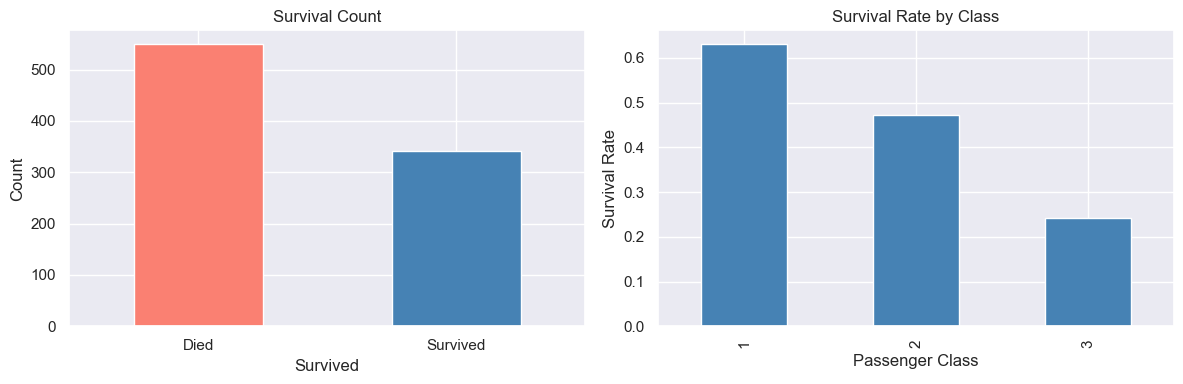

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Survival count
df['Survived'].value_counts().plot(kind='bar', ax=axes[0], color=['salmon', 'steelblue'])
axes[0].set_title('Survival Count')
axes[0].set_xticklabels(['Died', 'Survived'], rotation=0)
axes[0].set_ylabel('Count')

# Survival rate by class
df.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Survival Rate by Class')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

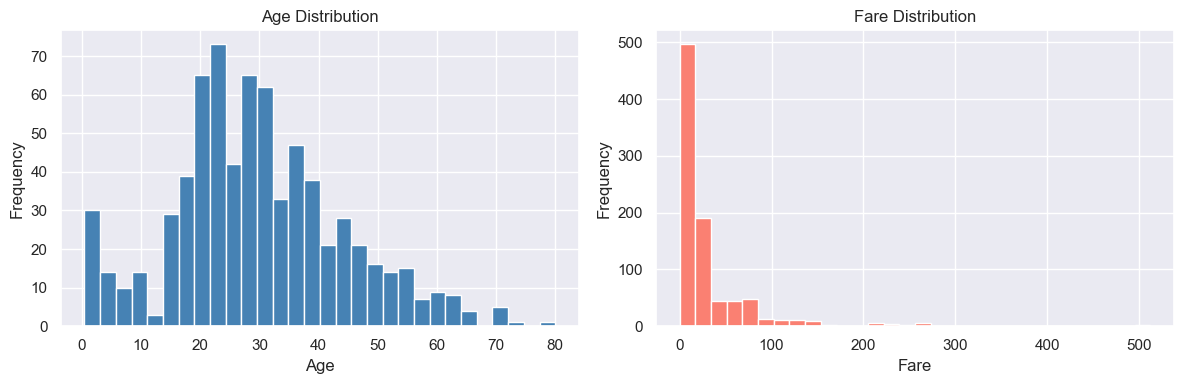

In [10]:
# ── Cell 5 — Age & Fare Distributions ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Age'].dropna().plot(kind='hist', bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')

df['Fare'].plot(kind='hist', bins=30, ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('Fare Distribution')
axes[1].set_xlabel('Fare')

plt.tight_layout()
plt.show()

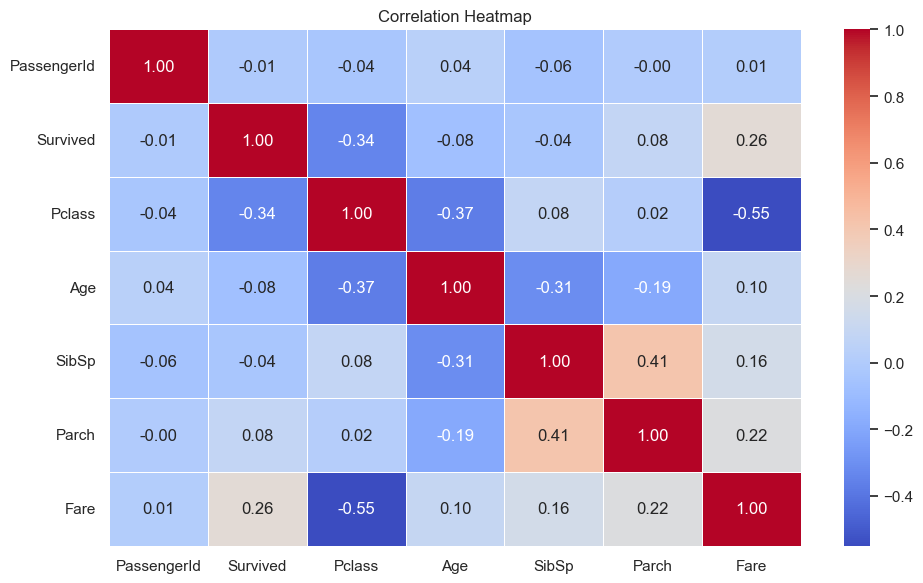

In [13]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True, fmt=".2f",
    cmap="coolwarm", ax=ax,
    linewidths=0.5
)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [15]:
survival_rate = df['Survived'].mean()
female_survival = df[df['Sex'] == 'female']['Survived'].mean()
male_survival = df[df['Sex'] == 'male']['Survived'].mean()
class1_survival = df[df['Pclass'] == 1]['Survived'].mean()
class3_survival = df[df['Pclass'] == 3]['Survived'].mean()

print("=== Key Insights ===")
print(f"Overall survival rate:     {survival_rate:.1%}")
print(f"Female survival rate:      {female_survival:.1%}")
print(f"Male survival rate:        {male_survival:.1%}")
print(f"1st class survival rate:   {class1_survival:.1%}")
print(f"3rd class survival rate:   {class3_survival:.1%}")

=== Key Insights ===
Overall survival rate:     38.4%
Female survival rate:      74.2%
Male survival rate:        18.9%
1st class survival rate:   63.0%
3rd class survival rate:   24.2%
